In [1]:
print("IPL cricket performance analysis project")


IPL cricket performance analysis project


In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

print("libraries imported successfully")

libraries imported successfully


In [4]:
import os
print(os.getcwd())

C:\Users\SRAVANTHI


In [5]:
import pandas as pd
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv.zip")

print("files loaded successfully")

files loaded successfully


In [6]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [8]:
matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [9]:
matches = matches.drop('umpire3',axis=1)

print("umpire3 column removed")

umpire3 column removed


In [10]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
dtypes: int64(5), object(12)
memory usag

In [13]:
print("total matches:" , matches.shape[0])

total matches: 756


In [14]:
matches['winner'].value_counts().head(10)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Name: count, dtype: int64

In [15]:
matches['city'].value_counts().head(10)

city
Mumbai        101
Kolkata        77
Delhi          74
Bangalore      66
Hyderabad      64
Chennai        57
Jaipur         47
Chandigarh     46
Pune           38
Durban         15
Name: count, dtype: int64

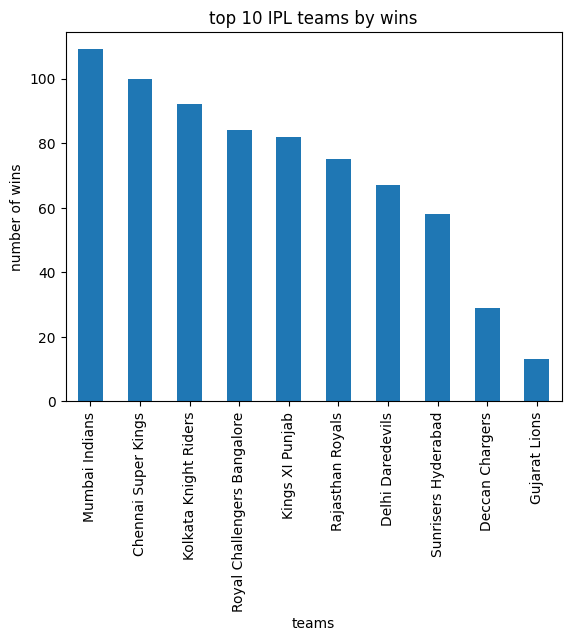

In [17]:
import matplotlib.pyplot as plt
matches['winner'].value_counts().head(10).plot(kind='bar')

plt.title("top 10 IPL teams by wins")
plt.xlabel("teams")
plt.ylabel("number of wins")

plt.show()


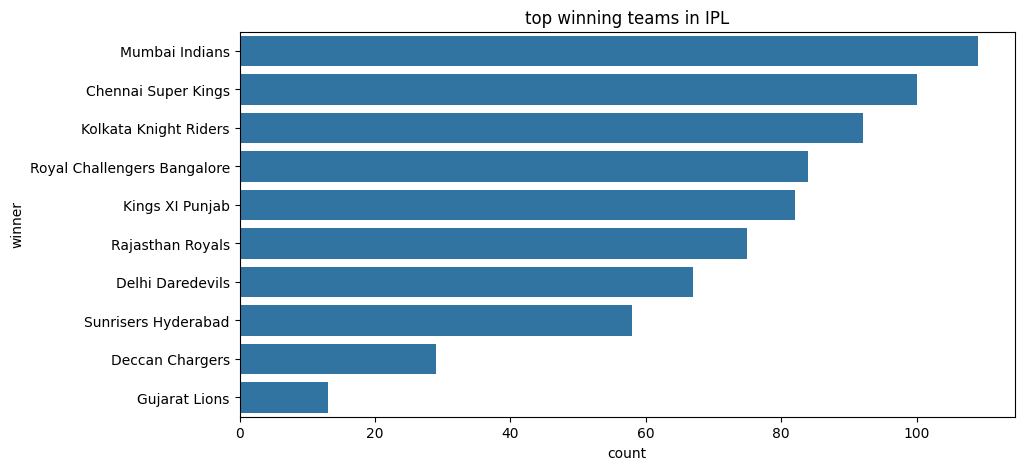

In [18]:
import seaborn as sns 
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,5))
sns.countplot(y=matches['winner'], order=matches['winner'].value_counts().index[:10])
plt.title("top winning teams in IPL")

plt.show()

In [19]:
sql_query_1 = """
select *  from matches;
"""
print(sql_query_1)


select *  from matches;



In [20]:
sql_query_2 = """
select * from matches
where winner = 'mumbai indians';
"""

print(sql_query_2)


select * from matches
where winner = 'mumbai indians';



In [21]:
sql_query_3 = """
select * from matches 
order by season desc ;
"""
print(sql_query_3)


select * from matches 
order by season desc ;



In [22]:
sql_query_4 = """
select winner'
count(*)as total_wins
from matches 
group by winner 
order by total_wins desc;
"""

print(sql_query_4)


select winner'
count(*)as total_wins
from matches 
group by winner 
order by total_wins desc;



In [25]:
matches.groupby('winner').size().sort_values(ascending=False).head(10)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
dtype: int64

In [28]:
matches['toss_match_win'] = matches['toss_winner'] == matches['winner']

matches['toss_match_win'].value_counts()

toss_match_win
True     393
False    363
Name: count, dtype: int64

In [29]:
matches['win_by_runs'].mean()

np.float64(13.283068783068783)

In [30]:
matches['win_by_runs'].median()

0.0

In [31]:
matches['win_by_runs'].var()

550.8946003714248

In [32]:
team_wins = matches.groupby('winner')['id'].count()
print(team_wins.sort_values(ascending=False).head(10))

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Name: id, dtype: int64


In [33]:
pivot = pd.pivot_table( matches, values ='id' , index = 'winner' , aggfunc = 'count' )
pivot.sort_values(by='id',ascending=False).head(10)

,id
winner,
Mumbai Indians,109
Chennai Super Kings,100
Kolkata Knight Riders,92
Royal Challengers Bangalore,84
Kings XI Punjab,82
Rajasthan Royals,75
Delhi Daredevils,67
Sunrisers Hyderabad,58
Deccan Chargers,29


In [35]:
matches['toss_match_win'] = ( matches['toss_winner']==  matches['winner'])
matches['toss_match_win'].value_counts()

toss_match_win
True     393
False    363
Name: count, dtype: int64

In [36]:
matches['win_by_runs'].describe()

count    756.000000
mean      13.283069
std       23.471144
min        0.000000
25%        0.000000
50%        0.000000
75%       19.000000
max      146.000000
Name: win_by_runs, dtype: float64

In [37]:
matches.groupby('season').size()

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
dtype: int64

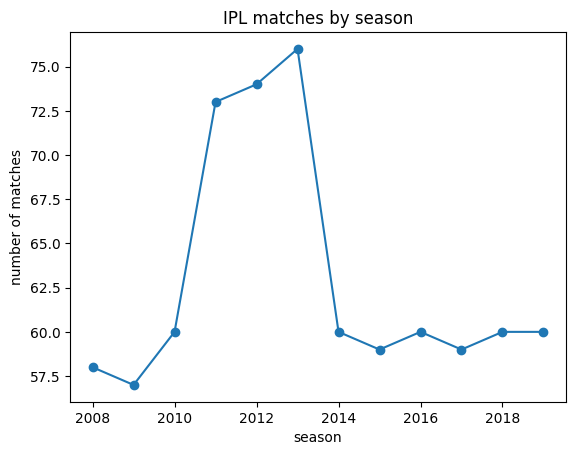

In [38]:
matches.groupby('season').size().plot(marker='o')

plt.title("IPL matches by season")
plt.xlabel("season")
plt.ylabel("number of matches")

plt.show()

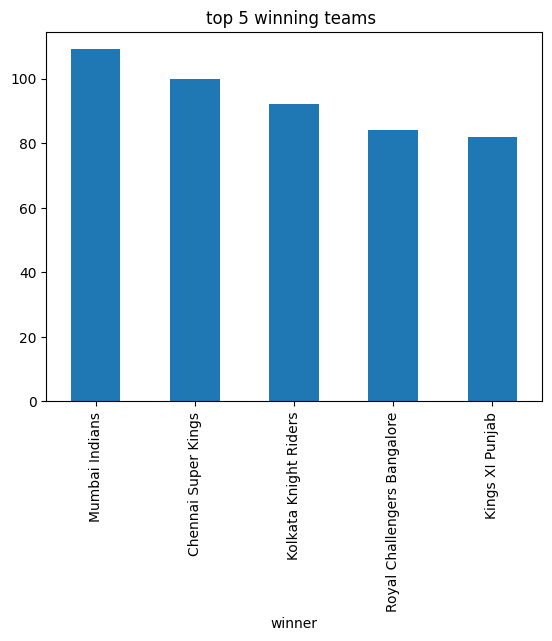

In [42]:
matches['winner'].value_counts().head(5).plot(kind='bar',title = 'top 5 winning teams ')

plt.show()
